In [1]:
import rasterio
from rasterio.warp import reproject, calculate_default_transform, Resampling
import logging
import os
import numpy as np
import pandas as pd
import re
import seaborn as sns
from rasterio.mask import mask
from pathlib import Path
import geopandas as gpd
import matplotlib.pyplot as plt

#### Data sources

In [2]:
classified_dir = '../../../data/processed/classified'
plots_path = '../../../data/shapes/analysis.shp'

In [14]:
plots = gpd.read_file(plots_path).to_crs('EPSG:32737')

In [3]:
#aligned rasters
lulc_2010 = os.path.join(classified_dir, 'lulc_2010.tif')
lulc_2015 = os.path.join(classified_dir, 'lulc_2015.tif')
lulc_2020 = os.path.join(classified_dir, 'lulc_2020.tif')
lulc_2025 = os.path.join(classified_dir, 'lulc_2025.tif')

#### Spatial coregistration and masking of classified images
* Ensures all images are in the same grid and resolution size to ensure compatibility and comparability

In [5]:
def coregister_raster(src_path: str, dest_path: str, ref_path: str) -> None:
        """Reproject and align raster to match reference raster."""
        #open the raster to be aligned
        with rasterio.open(src_path) as src:
            src_transform = src.transform
            #open the reference raster/ raster with target dimensions and resolution
            with rasterio.open(ref_path) as ref:
                dst_crs = ref.crs
                dst_transform, dst_width, dst_height = calculate_default_transform(
                    src.crs,    
                    dst_crs,    
                    ref.width,   
                    ref.height,  
                    *ref.bounds,
                )
                dst_kwargs = src.meta.copy()
                dst_kwargs.update({
                                "crs": dst_crs,
                                "transform": dst_transform,
                                "width": dst_width,
                                "height": dst_height,
                                "nodata": 0,
                                "dtype": src.meta["dtype"],})
                #write the aligned raster
                with rasterio.open(dest_path, 'w', **dst_kwargs) as dst:
                    for i in range(1, src.count + 1):
                        reproject(
                            source=rasterio.band(src, i),
                            destination=rasterio.band(dst, i),
                            src_transform=src.transform,
                            src_crs=src.crs,
                            dst_transform=dst_transform,
                            dst_crs=dst_crs,
                            resampling=Resampling.nearest#nearest resampling avoids overstretching rasters, esp given we are moving from 10m to around 3m
                        )

        print(f"Coregistered: {os.path.basename(src_path)} to {dest_path}")
            

In [6]:
def mask(src_file, plots_path, output_path):
    with rasterio.open(src_file) as src:
        crs = src.crs
        gdf = gpd.read_file(plots_path).to_crs('EPSG:4326')
        geoms = [feature["geometry"] for feature in gdf.__geo_interface__["features"]]
        out_image, out_transform = rasterio.mask.mask(src, geoms, crop=True)
        out_meta = src.meta
        out_meta.update({"driver": "GTiff",
            "height": out_image.shape[1],
            "width": out_image.shape[2],
            "transform": out_transform})
    with rasterio.open(output_path, 'w', **out_meta) as dest:
        dest.write(out_image)
    logging.info('Clipping complete.')

In [6]:
coregister_raster(lulc_2015, os.path.join(classified_dir, 'lulc_2015_aligned.tif'), lulc_2010)
coregister_raster(lulc_2020, os.path.join(classified_dir, 'lulc_2020_aligned.tif'), lulc_2010)
coregister_raster(lulc_2025, os.path.join(classified_dir, 'lulc_2025_aligned.tif'), lulc_2010)

Coregistered: lulc_2015.tif to ../../../data/processed/classified\lulc_2015_aligned.tif
Coregistered: lulc_2020.tif to ../../../data/processed/classified\lulc_2020_aligned.tif
Coregistered: lulc_2025.tif to ../../../data/processed/classified\lulc_2025_aligned.tif


* Update the coregistered paths images

In [4]:
lulc_2015 = os.path.join(classified_dir, 'lulc_2015_aligned.tif')
lulc_2020 = os.path.join(classified_dir, 'lulc_2020_aligned.tif')
lulc_2025 = os.path.join(classified_dir, 'lulc_2025_aligned.tif')
indices_path = '../../../data/processed/quarterly.csv'

#### Area occupied per class

In [8]:
def compute_landcover_area_single_raster(
    raster_path,
    class_map={1: "forest", 2: "sparse_woody", 3: "open", 4: "water"}
):
    """
    Computes area (km²) per landcover class for a single categorical raster.

    Parameters
    ----------
    raster_path : str or Path
        Path to categorical landcover raster.
    class_map : dict
        Mapping of class_id -> class_name.

    Returns
    -------
    pandas.DataFrame
        Columns: year, class_id, class_name, area_km2
    """

    raster_path = Path(raster_path)

    # ---- infer year from filename ----
    match = re.search(r"(19|20)\d{2}", raster_path.name)
    if not match:
        raise ValueError(f"Year not found in filename: {raster_path.name}")

    year = int(match.group())

    with rasterio.open(raster_path) as src:
        if not src.crs or not src.crs.is_projected:
            raise ValueError("Raster must be in a projected CRS for area calculation.")

        data = src.read(1)
        transform = src.transform
        nodata = src.nodata

        # ---- pixel area (m²) ----
        pixel_area_m2 = abs(transform.a * transform.e)

        # ---- mask NoData ----
        if nodata is not None:
            data = data[data != nodata]

        records = []

        for class_id, class_name in class_map.items():
            pixel_count = np.sum(data == class_id)
            area_km2 = (pixel_count * pixel_area_m2) / 1_000_000

            records.append({
                "year": year,
                "class_id": class_id,
                "class_name": class_name,
                "area_km2": area_km2
            })

    return pd.DataFrame(records)


In [9]:
area_2010 = compute_landcover_area_single_raster(lulc_2010)
area_2015 = compute_landcover_area_single_raster(lulc_2015)
area_2020 = compute_landcover_area_single_raster(lulc_2020)
area_2025 = compute_landcover_area_single_raster(lulc_2025)

In [10]:
area_2010

,year,class_id,class_name,area_km2
0,2010,1,forest,11.946581
1,2010,2,sparse_woody,39.870841
2,2010,3,open,13.043369
3,2010,4,water,1.709594


In [11]:
area_2015

,year,class_id,class_name,area_km2
0,2015,1,forest,15.831859
1,2015,2,sparse_woody,31.587676
2,2015,3,open,17.796415
3,2015,4,water,1.354435


In [12]:
area_2020

,year,class_id,class_name,area_km2
0,2020,1,forest,10.095639
1,2020,2,sparse_woody,25.666273
2,2020,3,open,29.223230
3,2020,4,water,1.585243


In [13]:
area_2025

,year,class_id,class_name,area_km2
0,2025,1,forest,20.791559
1,2025,2,sparse_woody,27.829432
2,2025,3,open,16.489395
3,2025,4,water,1.459998


#### Combine the yearly area dfs into one df for eary analysis

In [14]:
areas_df = pd.concat([area_2010, area_2015, area_2020, area_2025], ignore_index=True)
areas_df = areas_df.sort_values('year')

In [15]:
areas_df

,year,class_id,class_name,area_km2
0,2010,1,forest,11.946581
1,2010,2,sparse_woody,39.870841
2,2010,3,open,13.043369
3,2010,4,water,1.709594
4,2015,1,forest,15.831859
5,2015,2,sparse_woody,31.587676
6,2015,3,open,17.796415
7,2015,4,water,1.354435
8,2020,1,forest,10.095639
9,2020,2,sparse_woody,25.666273


#### Load vegetation indices time series

In [16]:
indices_df = pd.read_csv(indices_path)

In [17]:
indices_df.head()

,system:index,MSAVI,NDVI,end_date,quarter,start_date,total_rainfall_mm,year,.geo
0,0,0.101680,0.056642,2010-04-01,1,2010-01-01,673.832021,2010.0,"{""type"":""MultiPoint"",""coordinates"":[]}"
1,1,0.232545,0.131931,2010-07-01,2,2010-04-01,333.888974,2010.0,"{""type"":""MultiPoint"",""coordinates"":[]}"
2,2,0.176625,0.096867,2010-10-01,3,2010-07-01,1.604513,2010.0,"{""type"":""MultiPoint"",""coordinates"":[]}"
3,3,0.259829,0.157210,2011-01-01,4,2010-10-01,780.920853,2010.0,"{""type"":""MultiPoint"",""coordinates"":[]}"
4,4,0.310553,0.186506,2011-04-01,1,2011-01-01,549.917556,2011.0,"{""type"":""MultiPoint"",""coordinates"":[]}"


In [18]:
indices_df['year'] = indices_df['year'].astype('int')

In [19]:
target_years = [2010, 2015, 2020, 2025]

df_subset = indices_df[indices_df["year"].isin(target_years)].copy()

In [20]:
df_subset.isna().sum()


system:index         0
MSAVI                0
NDVI                 0
end_date             0
quarter              0
start_date           0
total_rainfall_mm    0
year                 0
.geo                 0
dtype: int64

In [106]:
agg_df = (
    df_subset
    .groupby("year")
    .agg(
        total_rainfall_mm=("total_rainfall_mm", "sum"),
        mean_ndvi=("NDVI", "mean"),
        mean_msavi=("MSAVI", "mean"),
        n_quarters=("year", "count")
    )
    .reset_index()
)

agg_df


,year,total_rainfall_mm,mean_ndvi,mean_msavi,n_quarters
0,2010,1790.246360,0.110662,0.192670,4
1,2015,2425.667748,0.159171,0.260128,4
2,2020,2408.514725,0.368177,0.500040,4
3,2025,2193.999462,0.185778,0.300788,4


In [107]:
type(areas_df)

pandas.DataFrame

#### Change detection plots
* Plot the area changes for each class against baseline

In [120]:
import seaborn as sns


def plot_landcover_change_vs_baseline(
    df,
    class_name,
    baseline_year=2010
):
    """
    Plots landcover area change for a single class against a no-change baseline.

    Parameters
    ----------
    df : pandas.DataFrame
        DataFrame containing year, class_name, area_km2
    class_name : str
        Landcover class to plot (e.g. 'forest')
    baseline_year : int
        Year used as counterfactual baseline
    """

    sns.set_theme(
        style="whitegrid",
        context="notebook"
    )

    class_df = (
        df[df["class_name"] == class_name]
        .sort_values("year")
        .copy()
    )

    if baseline_year not in class_df["year"].values:
        raise ValueError(f"{baseline_year} not found for {class_name}")

    baseline_area = class_df.loc[
        class_df["year"] == baseline_year, "area_km2"
    ].values[0]

    plt.figure(figsize=(9, 5))

    # Observed trend
    sns.lineplot(
        data=class_df,
        x="year",
        y="area_km2",
        marker="o",
        linewidth=3,
        label="Observed land-cover area"
    )

    # Baseline (no-change counterfactual)
    plt.axhline(
        y=baseline_area,
        linestyle="--",
        linewidth=2,
        color='red',
        label=f"{baseline_year} baseline (no change)"
    )

    plt.title(
        f"{class_name.replace('_', ' ').title()} Area Change Relative to Baseline",
        pad=15
    )
    plt.xlabel("Year")
    plt.ylabel("Area (km²)")
    plt.legend(frameon=False)

    sns.despine()
    plt.tight_layout()
    plt.savefig(f'{classified_dir}/{class_name}_change.png', dpi = 400)
    plt.show()


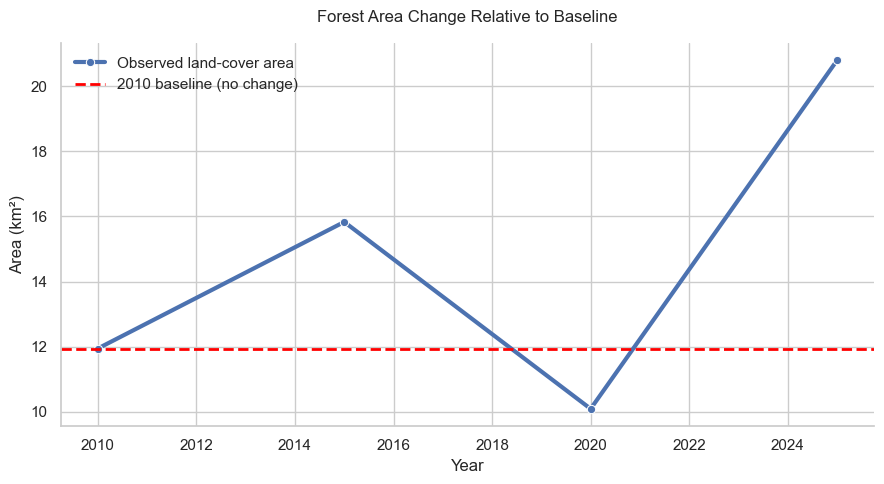

In [121]:
plot_landcover_change_vs_baseline(
    areas_df,
    class_name="forest"
)

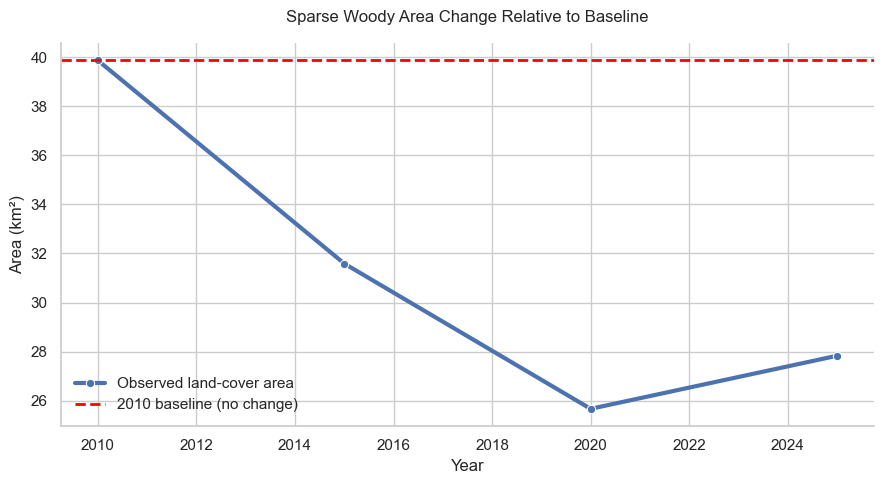

In [122]:
plot_landcover_change_vs_baseline(
    areas_df,
    class_name="sparse_woody"
)

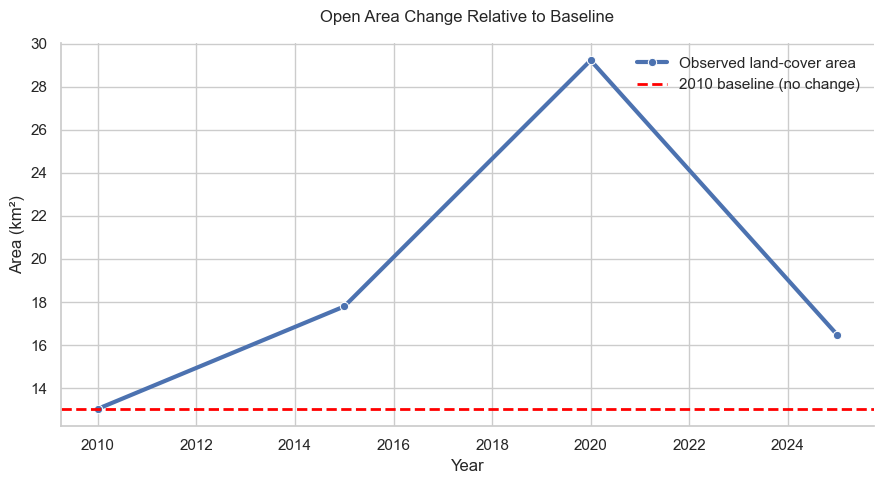

In [123]:
plot_landcover_change_vs_baseline(
    areas_df,
    class_name="open"
)

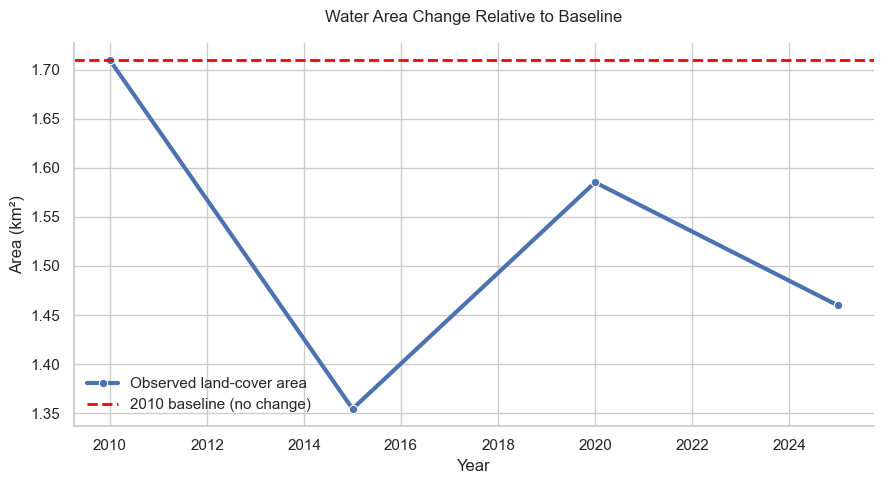

In [124]:
plot_landcover_change_vs_baseline(
    areas_df,
    class_name="water"
)

In [108]:
agg_df = (
    indices_df
    .groupby("year")
    .agg(
        total_rainfall_mm=("total_rainfall_mm", "sum"),
        mean_ndvi=("NDVI", "mean"),
        mean_msavi=("MSAVI", "mean"),
        n_quarters=("year", "count")
    )
    .reset_index()
)

agg_df


,year,total_rainfall_mm,mean_ndvi,mean_msavi,n_quarters
0,2010,1790.246360,0.110662,0.192670,4
1,2011,1746.795520,0.113897,0.198472,4
2,2012,1701.232715,NaN,NaN,4
3,2013,1649.924544,0.136641,0.226384,4
4,2014,1399.486615,0.162117,0.264163,4
5,2015,2425.667748,0.159171,0.260128,4
6,2016,1763.800486,0.139832,0.232049,4
7,2017,1312.297808,0.136710,0.230469,4
8,2018,2774.590478,0.337873,0.472616,4
9,2019,2553.893574,0.262699,0.377913,4


In [109]:
agg_df = agg_df.dropna()

#### Overlay with indices changes over time to bring out trends

In [127]:
def plot_ndvi_msavi_with_rainfall(df):
    """
    Clean dual-axis plot showing NDVI & MSAVI overlaid on rainfall.
    No smoothing, no regression.
    """

    sns.set_theme(style="whitegrid", context="notebook")
    df = df.sort_values("year")

    fig, ax1 = plt.subplots(figsize=(10, 5))

    # ---- Vegetation indices (LEFT axis) ----
    sns.lineplot(
        data=df,
        x="year",
        y="mean_ndvi",
        marker="o",
        linewidth=2.8,
        ax=ax1,
        label="NDVI"
    )

    sns.lineplot(
        data=df,
        x="year",
        y="mean_msavi",
        marker="s",
        linewidth=2.8,
        ax=ax1,
        label="MSAVI"
    )

    ax1.set_ylabel("Vegetation Index Value")
    ax1.set_xlabel("Year")
    ax1.set_ylim(0, 0.6)  # IMPORTANT: keep indices visible

    # ---- Rainfall (RIGHT axis, background) ----
    ax2 = ax1.twinx()
    ax2.bar(
        df["year"],
        df["total_rainfall_mm"],
        alpha=0.25,
        width=0.6,
        zorder=0
    )

    ax2.set_ylabel("Total Rainfall (mm)")

    # ---- Title & legend ----
    ax1.set_title(
        "NDVI and MSAVI in Relation to Annual Rainfall",
        pad=15
    )

    ax1.legend(frameon=False, loc="upper left")

    sns.despine(right=False)
    plt.tight_layout()
    plt.savefig(f'{classified_dir}/total_rainfall.png', dpi = 400)
    plt.show()

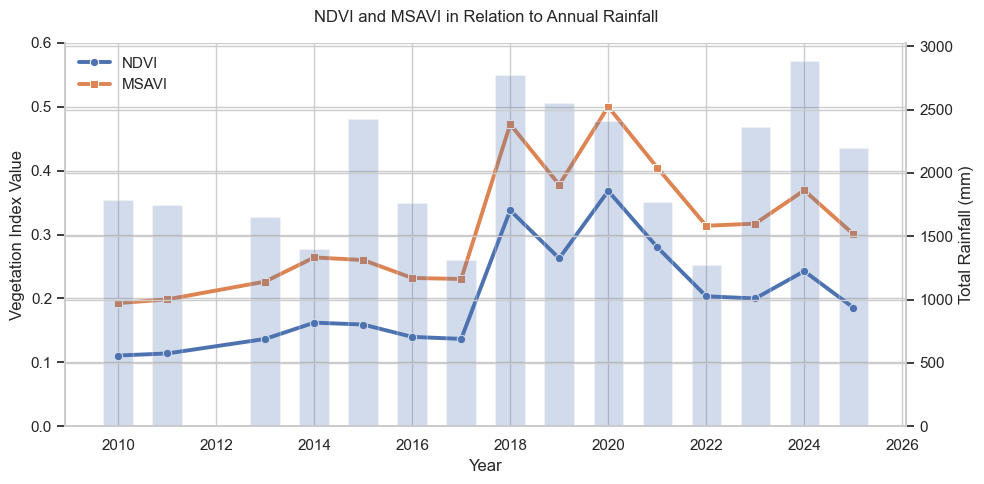

In [128]:
plot_ndvi_msavi_with_rainfall(agg_df)

### Individual plots transition matrices

In [5]:
raster_paths = {
    2010: lulc_2010, 
    2015: lulc_2015,
    2020: lulc_2020,
    2025: lulc_2025
}

In [15]:
def get_masked_data(raster_path, shapes):
    with rasterio.open(raster_path) as src:
        # Mask the raster with the plot geometries
        crs = src.crs
        gdf = gpd.read_file(plots_path).to_crs(crs)
        geoms = [feature["geometry"] for feature in gdf.__geo_interface__["features"]]
        out_image, out_transform = rasterio.mask.mask(src, geoms, crop=True)
        return out_image[0], src.nodata

In [16]:
# 2. Extract Statistics
results = []
class_names = {1: "forest", 2: "sparse_woody", 3: "open", 4: "water"} # Example classes

for year, path in raster_paths.items():
    data, nodata = get_masked_data(path, plots)
    unique, counts = np.unique(data[data != nodata], return_counts=True)
    
    for val, count in zip(unique, counts):
        results.append({
            'Year': year,
            'Class': class_names.get(val, f'Class_{val}'),
            'Pixel_Count': count,
            'Area_sqm': count * 30 * 30 # Assuming 30m resolution
        })

df_stats = pd.DataFrame(results)
# df_stats.to_csv('intervention_stats.csv', index=False)

In [17]:
df_stats.head()

,Year,Class,Pixel_Count,Area_sqm
0,2010,forest,132,118800
1,2010,sparse_woody,372,334800
2,2010,open,122,109800
3,2010,water,4,3600
4,2015,forest,121,108900


#### Transition matrix

In [18]:
# 3. Transition Matrix (2010 to 2020)
def compute_transition_matrix(year_start, year_end):
    start_data, _ = get_masked_data(raster_paths[year_start], plots.geometry)
    end_data, _ = get_masked_data(raster_paths[year_end], plots.geometry)
    
    # Flatten and filter out nodata
    valid = (start_data > 0) & (end_data > 0)
    s_flat = start_data[valid].flatten()
    e_flat = end_data[valid].flatten()
    
    # Create cross-tabulation
    matrix = pd.crosstab(
        pd.Series(s_flat, name=f'From_{year_start}'),
        pd.Series(e_flat, name=f'To_{year_end}'),
        normalize='index' # Provides probabilities
    )
    return matrix

In [19]:
transition_mat = compute_transition_matrix(2010, 2025)

In [20]:
transition_mat

To_2025,1,2,3,4
From_2010,,,,
1,0.272727,0.598485,0.128788,0.000000
2,0.158602,0.567204,0.274194,0.000000
3,0.106557,0.557377,0.327869,0.008197
4,0.250000,0.250000,0.500000,0.000000


Text(0.5, 1.0, 'Land Class Evolution in Intervention Plots')

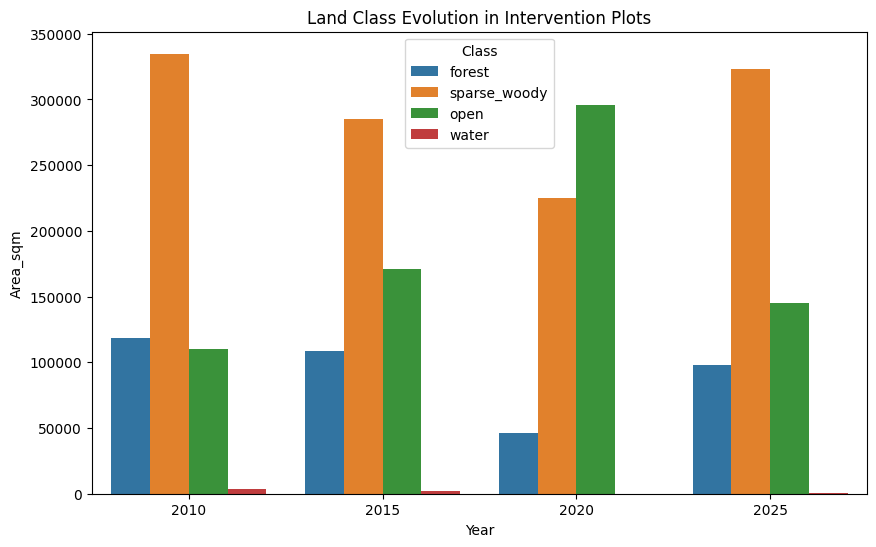

In [21]:
# 4. Visualization
plt.figure(figsize=(10, 6))
sns.barplot(data=df_stats, x='Year', y='Area_sqm', hue='Class')
plt.title('Land Class Evolution in Intervention Plots')
# plt.savefig('class_change_plot.png')

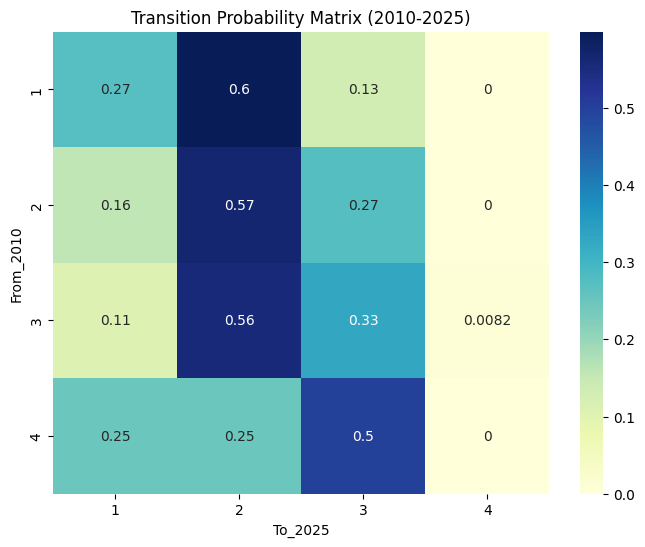

In [22]:
plt.figure(figsize=(8, 6))
sns.heatmap(transition_mat, annot=True, cmap='YlGnBu')
plt.title('Transition Probability Matrix (2010-2025)')
plt.show()

In [23]:
import plotly.express as px
import plotly.graph_objects as go

# 1. Visualizing Evolution (Stacked Area)
# Assuming 'df_stats' has columns: 'Year', 'Class', 'Area_sqm'
fig_area = px.area(df_stats, x="Year", y="Area_sqm", color="Class",
                   title="<b>Impact Assessment: Forest Expansion 2010–2025</b>",
                   color_discrete_map={
                       "Forest": "#2D5A27",    # Deep Forest Green
                       "Sparse Woody": "#99C945", # Meadow Green
                       "Open": "#D4A373",    # Earthy Brown
                       "Water": "#707B7C"      # Neutral Grey
                   },
                   template="plotly_white")

# Add a vertical 'Intervention Start' line for context
fig_area.add_vline(x=2012, line_dash="dash", line_color="red", 
                   annotation_text="Planting Phase Begins")

# 2. Transition Heatmap (2010 to 2020)
# 'transition_mat' from previous step
fig_heat = px.imshow(transition_mat,
                     labels=dict(x="2025 Class", y="2010 Class", color="Probability"),
                     x=list(class_names.values()),
                     y=list(class_names.values()),
                     color_continuous_scale='Greens',
                     title="<b>Where did the new trees come from?</b> (Transition Likelihood)")

fig_heat.update_traces(text=transition_mat.values.round(2), showscale=True)
fig_area.show()
fig_heat.show()

In [27]:
df_stats

,Year,Class,Pixel_Count,Area_sqm
0,2010,forest,132,118800
1,2010,sparse_woody,372,334800
2,2010,open,122,109800
3,2010,water,4,3600
4,2015,forest,121,108900
5,2015,sparse_woody,317,285300
6,2015,open,190,171000
7,2015,water,2,1800
8,2020,forest,51,45900
9,2020,sparse_woody,250,225000


In [38]:
def plot_landcover_intervention(
    df,
    class_name,
    baseline_year=2010
):
    """
    Plots landcover area change for a single class against a no-change baseline.

    Parameters
    ----------
    df : pandas.DataFrame
        DataFrame containing year, class_name, area_km2
    class_name : str
        Landcover class to plot (e.g. 'forest')
    baseline_year : int
        Year used as counterfactual baseline
    """

    sns.set_theme(
        style="whitegrid",
        context="notebook"
    )

    class_df = (
        df[df["Class"] == class_name]
        .sort_values("Year")
        .copy()
    )

    if baseline_year not in class_df["Year"].values:
        raise ValueError(f"{baseline_year} not found for {class_name}")

    baseline_area = class_df.loc[
        class_df["Year"] == baseline_year, "Area_sqm"
    ].values[0]

    plt.figure(figsize=(9, 5))

    # Observed trend
    sns.lineplot(
        data=class_df,
        x="Year",
        y="Area_sqm",
        marker="o",
        linewidth=3,
        label="Observed land-cover area"
    )

    # Baseline (no-change counterfactual)
    plt.axhline(
        y=baseline_area,
        linestyle="--",
        linewidth=2,
        color='red',
        label=f"{baseline_year} baseline (no change)"
    )

    plt.title(
        f"{class_name.replace('_', ' ').title()} Area Change in AWG Plots Relative to Baseline",
        pad=15
    )
    plt.xlabel("Year")
    plt.ylabel("Area (m²)")
    plt.legend(frameon=False)

    sns.despine()
    plt.tight_layout()
    plt.savefig(f'{classified_dir}/{class_name}_plots_change.png', dpi = 400)
    plt.show()


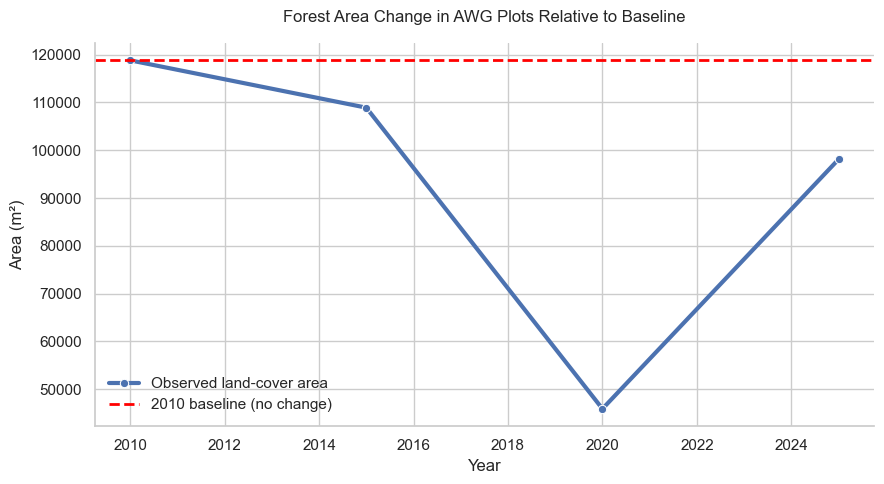

In [39]:
plot_landcover_intervention(df_stats, "forest")

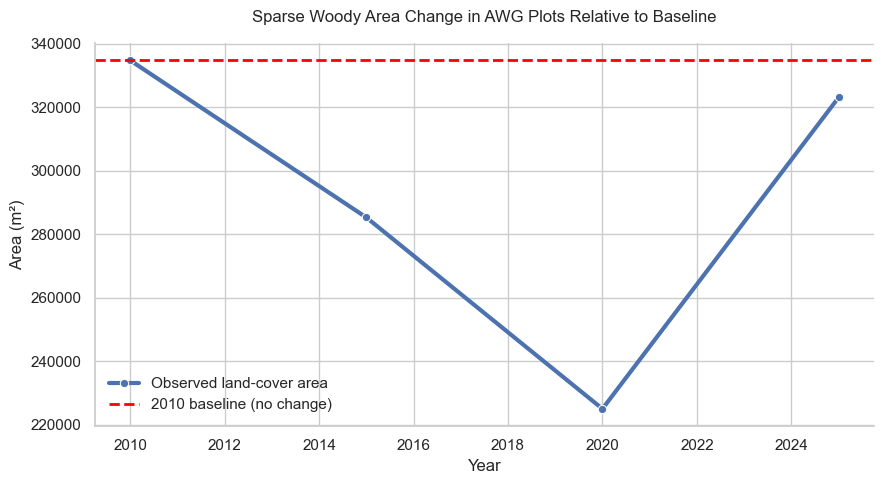

In [40]:
plot_landcover_intervention(df_stats, "sparse_woody")

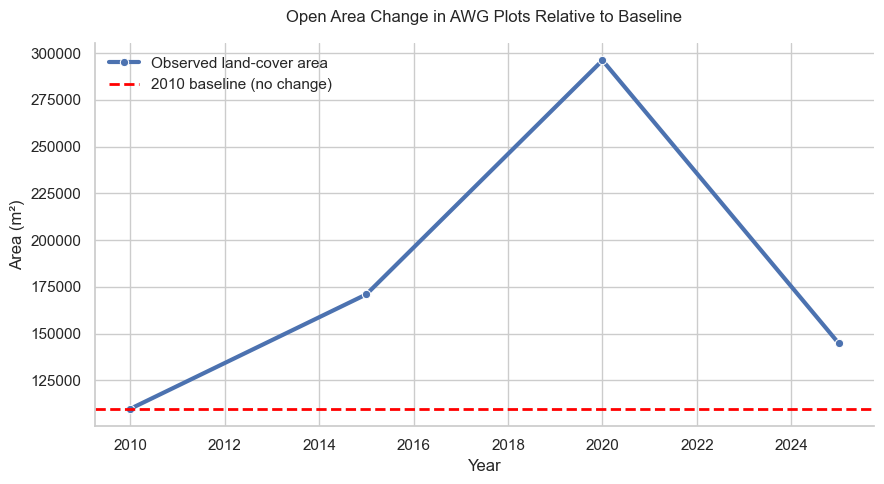

In [41]:
plot_landcover_intervention(df_stats, "open")